In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from natsort import natsorted
import matplotlib as mpl

# Add function path
original_path = os.getcwd()
os.chdir(original_path)
function_path = './functions/'
sys.path.append(function_path)

# Import custom functions
from analysis_function import *
from kcc_constrain_function import *
from Plot_function import *
from f1_0_H_sum_multi_region_constrain import *
from f_IMP import *
from f_schemes import *

# Journal-ready vector typography and exact-size tight PDF export.
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'pdf.fonttype': 42,
    'svg.fonttype': 'none',
})

from matplotlib.patches import Rectangle

def savefig_exact_tight(fig, path, width_mm, height_mm, title):
    fig.set_size_inches(width_mm / 25.4, height_mm / 25.4, forward=True)
    # This invisible full-canvas artist keeps bbox_inches='tight' at the
    # requested physical page size instead of cropping it unpredictably.
    frame = Rectangle(
        (0, 0), 1, 1, transform=fig.transFigure,
        fill=False, edgecolor='none', linewidth=0,
    )
    fig.add_artist(frame)
    fig.savefig(
        path, format='pdf', bbox_inches='tight', pad_inches=0,
        metadata={'Title': title},
    )


In [3]:
path = './saved_data/'
file_name = '2.0.real_obs_constrain_prior_post_warming_2016-2025_ref.1850-1900.nc'
prior_post_warm = xr.open_dataarray(path + file_name) 

file_name = '2.1.real_obs_constrain_prior_post_smoothed_series_1850-2025_ref.1850-1900.nc'
prior_post_smooth = xr.open_dataarray(path + file_name) 


def load_xr_pickle(filename):
    with open(filename, "rb") as f:
        return pickle.load(f)

obs_adj_ALL_ref1850 = load_xr_pickle(path + '2.3_adjust_obs_warming_ref1850_1850-2100.pkl')




### Calculating on large ensemble std(iv)

In [4]:
def load_xr_pickle(filename):
    with open(filename, "rb") as f:
        return pickle.load(f)

path = './saved_data/'

ln_mod_all = load_xr_pickle(path + '0.3.Large_ensembles.320runs.nonmasked.Tas.anomalies.46AR6regions_7cont_1glob_251years_1850-2100.pkl')

ln_mod_warming = change_ref(ln_mod_all, 1850, 1900).sel(year = slice(2016, 2025)).mean('year')

### the correct way of calculating std(IV)
pseudo_group = list(ln_mod_warming.groupby('model_name'))
pseudo_group_va = [da for name, da in ln_mod_warming.groupby('model_name')]

all_s2 = []

for pseudo_id in range(len(pseudo_group_va)):

    pseudo_ref = pseudo_group_va[pseudo_id].mean(['model_run'])

    bb = ((pseudo_group_va[pseudo_id] - pseudo_ref) ** 2).sum(dim="model_run")

    all_s2.append(bb)

all_s2_xr = xr.concat(all_s2, dim = 'pseudo_id')

counts = ln_mod_warming.groupby('model_name').count(dim='model_run') 
df_total = (counts - 1).sum(dim='model_name')
df_total

pseudo_iv_ln = np.sqrt(all_s2_xr.sum('pseudo_id') / df_total)
pseudo_iv_ln = xr.concat([pseudo_iv_ln.isel(region = slice(0,46)),pseudo_iv_ln.isel(region = 53)], dim = 'region')

### Plot bar chart of abs magnitude

In [5]:
labels = prior_post_warm.coords['abbrevs'].values

groups = {
    'North and Central America': ['GIC', 'NWN', 'NEN', 'WNA', 'CNA', 'ENA', 'NCA', 'SCA', 'CAR'],
    'South America': ['NWS', 'NSA', 'NES', 'SAM', 'SWS', 'SES', 'SSA'],
    'Europe': ['NEU', 'WCE', 'EEU', 'MED'],
    'Africa': ['SAH', 'WAF', 'CAF', 'NEAF', 'SEAF', 'WSAF', 'ESAF', 'MDG'],
    'Asia': ['RAR', 'WSB', 'ESB', 'RFE', 'WCA', 'ECA', 'TIB', 'EAS', 'ARP', 'SAS'],
    'Australasia': ['SEA', 'NAU', 'CAU', 'EAU', 'SAU', 'NZ'],
    'Antarctica': ['EAN', 'WAN'],
    'Global land': ['LSAT']
}

# Create a mapping from abbrev to index
abbrev_to_index = {abbr: i for i, abbr in enumerate(labels)}
continent_indices = {k: [abbrev_to_index[abbr] for abbr in v] for k, v in groups.items()}


colors = {
    'North and Central America': '#c45a5c',  # soft green
    'South America': '#a9b5da',               # lavender blue
    'Europe': '#f5a966',                      # warm yellow-orange
    'Africa': '#bab1a0',                      # muted red
    'Asia': '#b47955',                        # light blue
    'Australasia': '#6e9c6d',                 # forest green
    'Antarctica': '#5590B4',                   # brick red
    'Global land': '#dda15e'
}

uncertainty_ref_period=(1850, 2025)
ref_period=(1850, 1900)
obs_adjust_ref_period=(1961, 2023)
warming_target_period=(2016, 2025)

/var/folders/jt/kr53pz_j4x3d_32xbfb7pkd87_b0mf/T/ipykernel_62937/3487945480.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = cm.get_cmap(name)


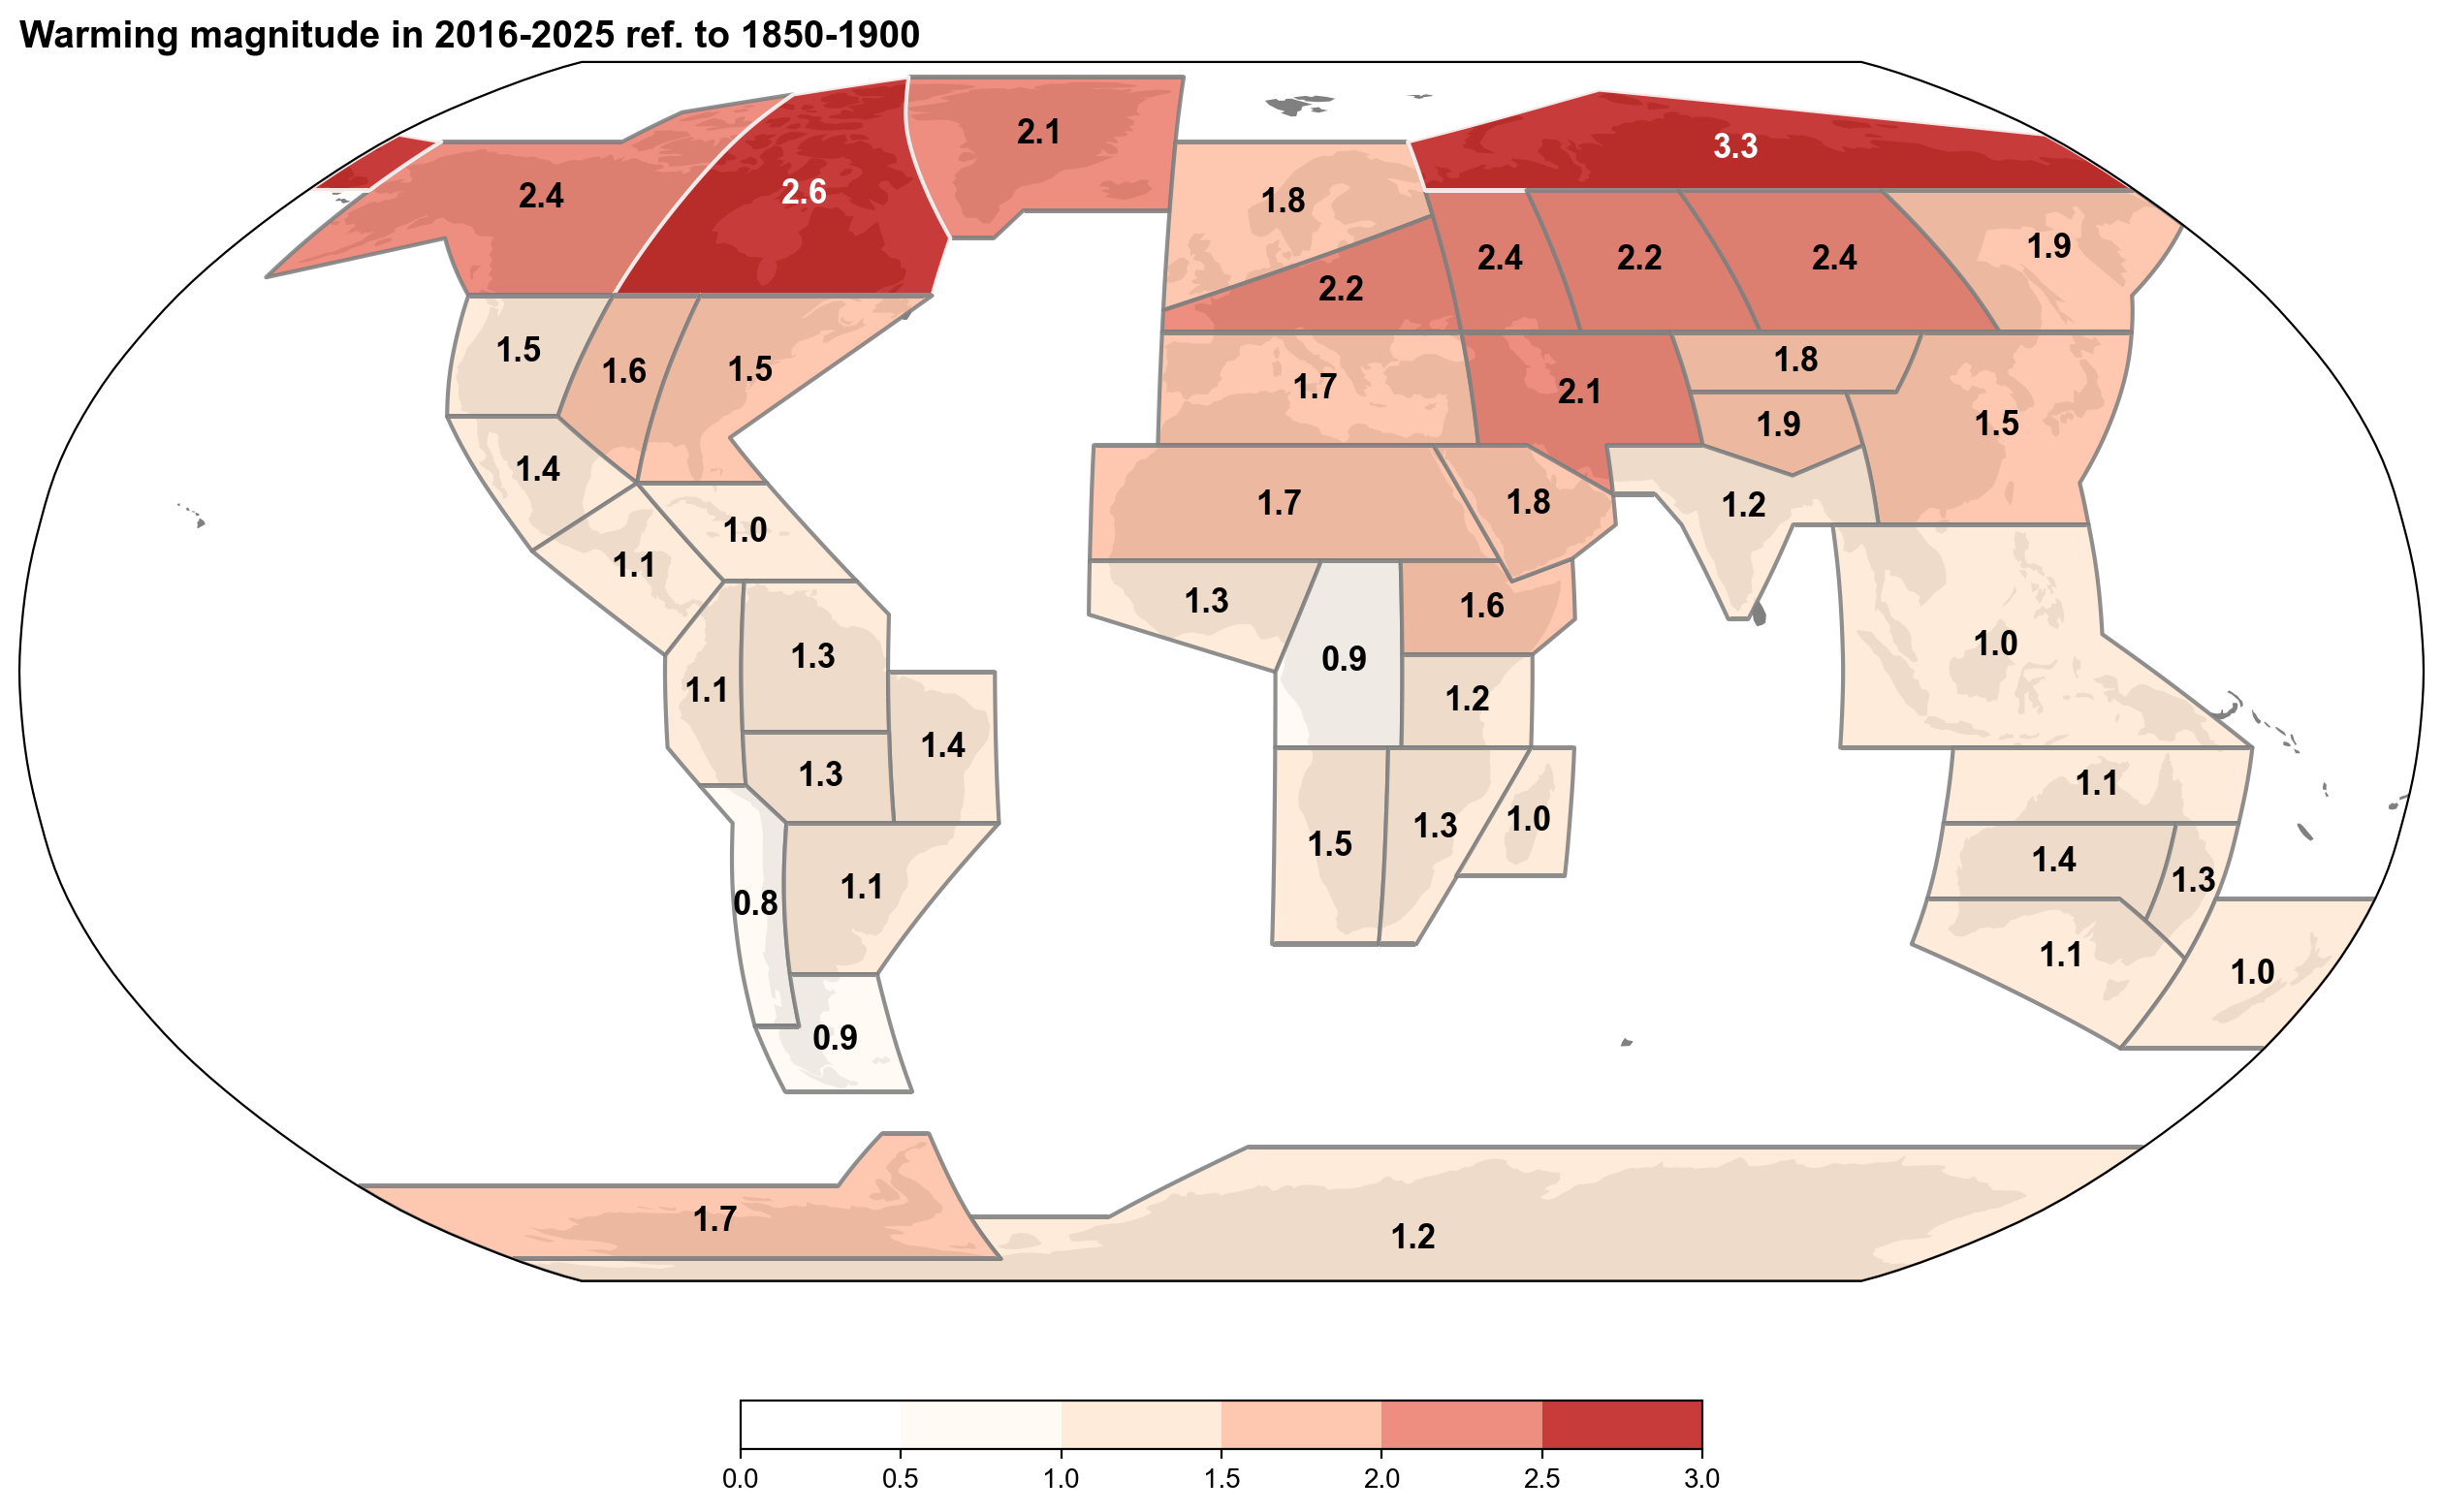

In [6]:
post_warming_map = prior_post_warm.sel(scheme = 'post', forcing = 'ALL', quantile = 'mean').isel(region = slice(0, 46))
post_warming_map


from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

def modify_cmap(name='YlGn', start=0.1, end=0.9, gamma=0.8, white_strength=0.3):
    """
    white_strength = 0 → no whitening
    white_strength = 1 → pure white at start
    """
    base = cm.get_cmap(name)
    colors = base(np.linspace(start, end, 256))[:, :3] ** gamma
    
    # Blend first colors toward white
    white = np.array([1, 1, 1])
    for i in range(len(colors)):
        blend_factor = (1 - i / (len(colors)-1)) * white_strength
        colors[i] = (1-blend_factor)*colors[i] + blend_factor*white
    
    return ListedColormap(colors)


cmap = modify_cmap('OrRd', start=0.0, end=0.95, gamma=1.0, white_strength=1.0)

colors_array = cmap(np.linspace(0, 1, 256))
truncated_colors = colors_array[0:230]
truncated_cmap = mcolors.LinearSegmentedColormap.from_list('truncated_YlOrBr', truncated_colors)


# --- Plot panels ---
fig, axes = plt.subplots(1,1, figsize=(16, 16), subplot_kw={'projection': ccrs.Robinson()}, dpi=200)

axes.set_global()

bounds = np.arange(0.0, 3.5, 0.5)
norm = mcolors.BoundaryNorm(boundaries=bounds, ncolors=256, extend='neither')

norm0 = plot_ar6_region_data_on_ax_new(axes, post_warming_map, cmap=truncated_cmap, norm=norm, decimals=1)
axes.set_title("Warming magnitude in 2016-2025 ref. to 1850-1900", fontsize=14, fontweight='bold', loc='left')
# axes.set_title("a", fontsize=14, fontweight='bold', loc='left')

# --- Shared colorbar ---
def set_cmap_alpha(cmap, alpha=1.0):
    """Return a copy of cmap with uniform alpha applied."""
    colors = cmap(np.arange(cmap.N))       # RGBA array
    colors[:, -1] = alpha                  # set alpha channel
    return mpl.colors.ListedColormap(colors)

# Example usage
cmap_with_alpha = set_cmap_alpha(truncated_cmap, alpha=0.88)

sm = mpl.cm.ScalarMappable(cmap=cmap_with_alpha, norm=norm0)
sm.set_array([])

cb = fig.colorbar(sm, ax=axes, orientation='horizontal', pad=0.05, shrink=0.4)



plt.show()

In [7]:
(prior_post_warm.sel(scheme = 'post', forcing = 'ALL', quantile = '5th').isel(region = slice(0, 46))>1).sum()

<xarray.DataArray 'prior_warming' ()> Size: 8B
array(28)
Coordinates:
    forcing      <U3 12B 'ALL'
    quantile     <U4 16B '5th'
    realization  int64 8B ...
    scheme       <U5 20B 'post'

/var/folders/jt/kr53pz_j4x3d_32xbfb7pkd87_b0mf/T/ipykernel_62937/3487945480.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = cm.get_cmap(name)


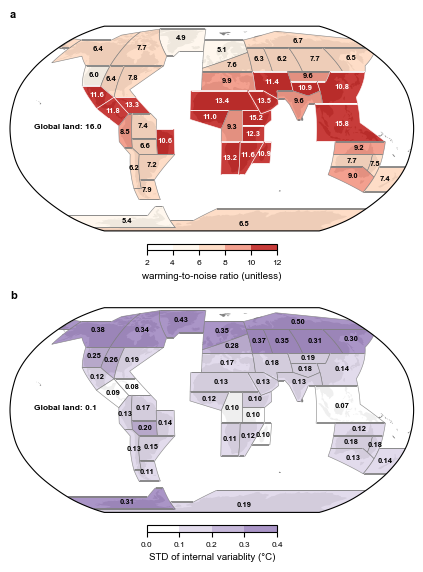

In [8]:
### Data preparation
post_warming_map = prior_post_warm.sel(scheme = 'post', forcing = 'ALL', quantile = 'mean')

warming_iv_std = post_warming_map / pseudo_iv_ln.assign_coords(region=post_warming_map['region'])

warming_iv_ratio_region = warming_iv_std.isel(region = slice(0,46))

std_iv_region = pseudo_iv_ln.assign_coords(region=post_warming_map['region']).isel(region = slice(0,46))

warming_iv_ratio_glob = warming_iv_std.isel(region = 46)

std_iv_glob = pseudo_iv_ln.assign_coords(glob=post_warming_map['region']).isel(region = 46)
unit = ' '

#### plot
cmap = modify_cmap('OrRd', start=0.0, end=0.95, gamma=1.0, white_strength=1.0)

colors_array = cmap(np.linspace(0, 1, 256))
truncated_colors = colors_array[0:230]
truncated_cmap = mcolors.LinearSegmentedColormap.from_list('truncated_YlOrBr', truncated_colors)

# --- Plot panels ---
ED2_WIDTH_MM, ED2_HEIGHT_MM = 180, 150
fig, axes = plt.subplots(2, 1, figsize=(ED2_WIDTH_MM / 25.4, ED2_HEIGHT_MM / 25.4), subplot_kw={'projection': ccrs.Robinson()})

ax = axes[0]

ax.set_global()

bounds = np.arange(2, 14, 2)
norm = mcolors.BoundaryNorm(boundaries=bounds, ncolors=256, extend='neither')

norm0 = plot_ar6_region_data_on_ax_new(ax, warming_iv_ratio_region, cmap=truncated_cmap, norm=norm, decimals=1, linewidth=0.45, label_fontsize=5.5)
ax.set_title("Warming magnitude / std (IV) (Fig. S2a)", fontsize=14, fontweight='bold', loc='left')
ax.set_title("a", fontsize=8.0, fontweight='bold', loc='left')


ax.text(
            0.06, 0.5,
            f"Global land: {warming_iv_ratio_glob:.1f}{unit}",   # unit inserted here
            transform=ax.transAxes,
            fontsize=6.0,
            fontweight='bold',
            color='black',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=4)
        )

def set_cmap_alpha(cmap, alpha=1.0):
    """Return a copy of cmap with uniform alpha applied."""
    colors = cmap(np.arange(cmap.N))       # RGBA array
    colors[:, -1] = alpha                  # set alpha channel
    return mpl.colors.ListedColormap(colors)

cmap_with_alpha = set_cmap_alpha(truncated_cmap, alpha=0.88)

sm = mpl.cm.ScalarMappable(cmap=cmap_with_alpha, norm=norm0)
sm.set_array([])

cb = fig.colorbar(sm, ax=ax, orientation='horizontal', pad=0.05, shrink=0.2)
cb.ax.tick_params(labelsize=6.0)   # change 14 to any size you want
cb.set_label("warming-to-noise ratio (unitless)", fontsize=7.0)


############# Panel b
ax = axes[1]


from matplotlib.colors import LinearSegmentedColormap

cmap = LinearSegmentedColormap.from_list("red_white", ["white", "#9f86c0"])

colors_array = cmap(np.linspace(0, 1, 256))
truncated_colors = colors_array[0:256]
truncated_cmap = mcolors.LinearSegmentedColormap.from_list('truncated_YlOrBr', truncated_colors)


ax.set_global()

bounds = np.arange(0, 0.5, 0.1)
norm = mcolors.BoundaryNorm(boundaries=bounds, ncolors=256, extend='neither')

norm0 = plot_ar6_region_data_on_ax_new(ax, std_iv_region, cmap=truncated_cmap, norm=norm, decimals=2, linewidth=0.45, label_fontsize=5.5)
ax.set_title("Standard deviation of IV (Fig. S2b)", fontsize=14, fontweight='bold', loc='left')
ax.set_title("b", fontsize=8.0, fontweight='bold', loc='left')

ax.text(
            0.06, 0.5,
            f"Global land: {std_iv_glob:.1f}{unit}",   # unit inserted here
            transform=ax.transAxes,
            fontsize=6.0,
            fontweight='bold',
            color='black',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=4)
        )

# --- Shared colorbar ---
# Example usage
cmap_with_alpha = set_cmap_alpha(truncated_cmap, alpha=0.88)

sm = mpl.cm.ScalarMappable(cmap=cmap_with_alpha, norm=norm0)
sm.set_array([])

cb = fig.colorbar(sm, ax=ax, orientation='horizontal', pad=0.05, shrink=0.2)
cb.ax.tick_params(labelsize=6.0)   # change 14 to any size you want
cb.set_label("STD of internal variablity (°C)", fontsize=7.0)

fig.subplots_adjust(left=0.04, right=0.96, top=0.97, bottom=0.06, hspace=0.1)

plt.show()
fig.savefig('./saved_figures/ED_Fig2.pdf', format='pdf', bbox_inches='tight', pad_inches=0.1, metadata={'Title': 'Extended Data Figure 2'})


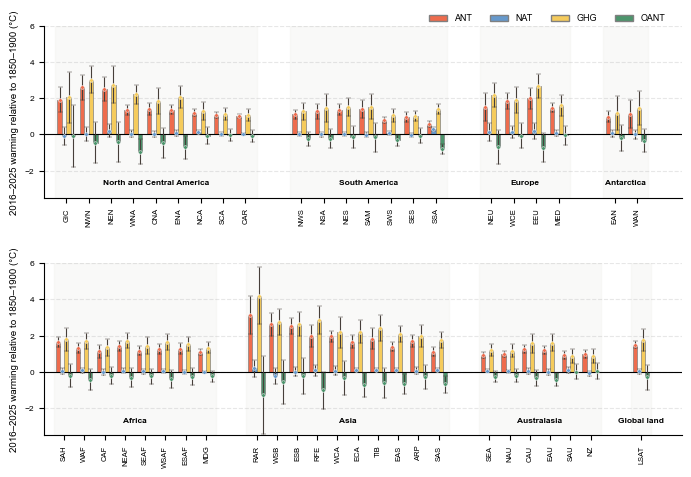

In [9]:
def plot_grouped_forcing_panel(ax, data_dict, title, colors_continent, continent_indices, labels, y_label, 
                               continent_height_value=-1, ylim_low=-1, ylim_high=6, continent_label='True', show_uncertainty=True):
    """
    Plot grouped bar chart for forcing responses (handles positive and negative values).
    
    Parameters:
    -----------
    data_dict : dict
        Dictionary with forcing names as keys, xarray DataArrays as values (with all quantiles)
    show_uncertainty : bool, default=True
        If True, display error bars (5th-95th percentile range)
    """
    bar_width = 0.2
    gap = 1.5
    
    x_ticks = []
    x_labels = []
    current_x = 0
    
    # Color scheme for forcings
    forcing_colors = {
        'ANT': '#ee6c4d',
        'NAT': '#6699CC',
        'GHG': '#F5CB5C',
        'OA': '#4C956C'
    }

    forcing_order = ['ANT', 'NAT', 'GHG', 'OA']
    
    # Plot grouped bars
    for continent, indices in continent_indices.items():
        for idx in indices:
            # Plot 4 bars side-by-side for this region
            for i, forcing in enumerate(forcing_order):
                mean_value = data_dict[forcing].sel(quantile='mean').values[idx]
                offset = (i - 1.5) * bar_width  # center the 4 bars
                
                # Calculate error bars if needed
                yerr = None
                if show_uncertainty:
                    err_lower = mean_value - data_dict[forcing].sel(quantile='5th').values[idx]
                    err_upper = data_dict[forcing].sel(quantile='95th').values[idx] - mean_value
                    yerr = [[err_lower], [err_upper]]
                
                ax.bar(current_x + offset, mean_value,
                       color=forcing_colors[forcing], width=bar_width,
                       edgecolor='gray', linewidth=0.5, zorder=2)
                if show_uncertainty:
                    ax.errorbar(
                        current_x + offset, mean_value, yerr=yerr, fmt='o',
                        ms=2.6, mfc=forcing_colors[forcing], mec='white', mew=0.35,
                        ecolor='#463f3a', elinewidth=0.8, capsize=1.8,
                        capthick=0.8, zorder=4,
                    )
            
            x_ticks.append(current_x)
            x_labels.append(labels[idx])
            current_x += 1
        current_x += gap
    
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, rotation=90, fontsize=5.5)
    ax.set_ylabel(y_label, fontsize=7.0)
    ax.tick_params(axis='y', labelsize=6.0)
    ax.set_title(title, loc='left', fontsize=8.0, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.grid(True, axis='y', linestyle='--', alpha=0.3)
    
    # Background and continent labels
    current_x = 0
    for continent, indices in continent_indices.items():
        group_width = len(indices)
        ax.axvspan(current_x - 0.5, current_x + group_width - 0.5, color='#edede9', alpha=0.3)
        group_center = current_x + group_width / 2 - 0.5
        
        if continent_label == 'True':
            ax.text(group_center, continent_height_value,
                    continent, ha='center', va='top', fontsize=6.0, fontweight='bold')
        current_x += group_width + gap
    
    ax.set_ylim(ylim_low, ylim_high)
    ax.set_xlim(-1, current_x - gap + 1)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


# ============================================
# Split regions into two rows
# ============================================

# Define two sets of continent groups
continent_indices_row1 = {
    "North and Central America": continent_indices["North and Central America"],
    "South America": continent_indices["South America"],
    "Europe": continent_indices["Europe"],
    "Antarctica": continent_indices["Antarctica"],
}

continent_indices_row2 = {
    "Africa": continent_indices["Africa"],
    "Asia": continent_indices["Asia"],
    "Australasia": continent_indices["Australasia"],
    "Global land": continent_indices["Global land"],
}

# Prepare forcing data (keep all quantiles for uncertainty visualization)
forcing_data = {
    'ANT': prior_post_warm.sel(scheme='post', forcing='ANT'),
    'NAT': prior_post_warm.sel(scheme='post', forcing='NAT'),
    'GHG': prior_post_warm.sel(scheme='post', forcing='GHG'),
    'OA': prior_post_warm.sel(scheme='post', forcing='OA')
}
# Create figure with 2 rows
FIG3_WIDTH_MM, FIG3_HEIGHT_MM = 180, 130
fig, axs = plt.subplots(2, 1, figsize=(FIG3_WIDTH_MM / 25.4, FIG3_HEIGHT_MM / 25.4), sharey=True)

# Row 1
plot_grouped_forcing_panel(
    axs[0], forcing_data, ' ',
    colors, continent_indices_row1, labels,
    '2016–2025 warming relative to 1850–1900 (°C)',
    continent_height_value=-2.5,
    ylim_low=-3.5, ylim_high=6,
    continent_label='True',
    show_uncertainty=True  # Set to False to hide uncertainty bars
)

# Row 2
plot_grouped_forcing_panel(
    axs[1], forcing_data, ' ',
    colors, continent_indices_row2, labels,
    '2016–2025 warming relative to 1850–1900 (°C)',
    continent_height_value=-2.5,
    ylim_low=-3.5, ylim_high=6,
    continent_label='True',
    show_uncertainty=True  # Set to False to hide uncertainty bars
)

# Add legend (shared for both rows)
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#ee6c4d', edgecolor='gray', linewidth=1, label='ANT'),
    Patch(facecolor='#6699CC', edgecolor='gray', linewidth=1, label='NAT'),
    Patch(facecolor='#F5CB5C', edgecolor='gray', linewidth=1, label='GHG'),
    Patch(facecolor='#4C956C', edgecolor='gray', linewidth=1, label='OANT')
]
fig.legend(handles=legend_elements, loc='lower center', fontsize=6.5, frameon=False, 
           ncol=4, bbox_to_anchor=(0.8, 0.9))

fig.subplots_adjust(left=0.09, right=0.99, top=0.91, bottom=0.11, hspace=0.38)
plt.show() 
savefig_exact_tight(fig, './saved_figures/Fig_3.pdf', FIG3_WIDTH_MM, FIG3_HEIGHT_MM, 'Figure 3')


In [10]:
ratio_ghg_all = ((prior_post_warm.sel(scheme = 'post', forcing = 'GHG') - prior_post_warm.sel(scheme = 'post', forcing = 'ALL'))/ prior_post_warm.sel(scheme = 'post', forcing = 'ALL')).sel(quantile = 'mean')

ratio_ghg_all.quantile([0.25, 0.75])

<xarray.DataArray 'prior_warming' (quantile: 2)> Size: 16B
array([0.03888359, 0.26260943])
Coordinates:
  * quantile  (quantile) float64 16B 0.25 0.75

In [11]:
from scipy.stats import pearsonr, t

# Select the observed ALL-forcing series and the posterior mean.
obs_all = obs_adj_ALL_ref1850.sel(forcing='ALL', drop=True)
post_mean = prior_post_smooth.sel(scheme='post', quantile='mean')

# Restrict both arrays to their shared region/year coordinates.
obs_all, post_mean = xr.align(obs_all, post_mean, join='inner')

# Each region has its own valid-observation years. This (region, year)
# mask broadcasts across all forcings in post_mean.
obs_valid_mask = obs_all.notnull()
post_mean_obs_years = post_mean.where(obs_valid_mask)

# Pearson correlation over the valid years, for every region and forcing.
corr_region_forcing = xr.corr(
    post_mean_obs_years, obs_all, dim='year'
).rename('pearson_r')
n_obs_years = obs_valid_mask.sum('year').rename('n_obs_years')

# Do not report correlations for regions with fewer than 30 observed years.
corr_region_forcing = corr_region_forcing.where(n_obs_years >= 30)

def correlation_ar1_adjusted(obs, signal):
    """Pearson r with an approximate AR(1)-adjusted two-sided p value."""
    obs, signal = xr.align(obs, signal, join='inner')

    valid = np.isfinite(obs.values) & np.isfinite(signal.values)
    y = obs.values[valid]
    x = signal.values[valid]

    n = len(x)
    if n < 30 or np.ptp(x) == 0 or np.ptp(y) == 0:
        return np.nan, np.nan, np.nan

    # Descriptive Pearson correlation.
    r = pearsonr(x, y).statistic

    # Lag-1 autocorrelations used to approximate the effective sample size.
    r1_x = pearsonr(x[:-1], x[1:]).statistic
    r1_y = pearsonr(y[:-1], y[1:]).statistic
    if not np.isfinite(r1_x) or not np.isfinite(r1_y):
        return r, np.nan, np.nan

    n_eff = n * (1 - r1_x * r1_y) / (1 + r1_x * r1_y)
    n_eff = np.clip(n_eff, 3, n)

    if np.isclose(np.abs(r), 1.0):
        p_adjusted = 0.0
    else:
        t_stat = r * np.sqrt((n_eff - 2) / (1 - r**2))
        p_adjusted = 2 * t.sf(np.abs(t_stat), df=n_eff - 2)

    return r, p_adjusted, n_eff


# AR(1)-adjusted two-sided p values for every region and forcing.
alpha = 0.05
p_values = xr.full_like(
    corr_region_forcing, np.nan, dtype=float
).rename('pearson_p_ar1_adjusted')
n_effective = xr.full_like(
    corr_region_forcing, np.nan, dtype=float
).rename('n_effective_ar1')
for region in corr_region_forcing.region.values:
    obs_series = obs_all.sel(region=region)
    for forcing in corr_region_forcing.forcing.values:
        signal_series = post_mean.sel(region=region, forcing=forcing)
        paired_valid = np.isfinite(obs_series.values) & np.isfinite(signal_series.values)
        if paired_valid.sum() < 30:
            continue

        r, p_adjusted, n_eff = correlation_ar1_adjusted(
            obs_series, signal_series
        )
        corr_region_forcing.loc[dict(region=region, forcing=forcing)] = r
        p_values.loc[dict(region=region, forcing=forcing)] = p_adjusted
        n_effective.loc[dict(region=region, forcing=forcing)] = n_eff

significant = (p_values < alpha).rename('pearson_significant')

def region_labels(mask):
    return [
        f"{corr_region_forcing['abbrevs'].sel(region=region).item()} "
        f"({corr_region_forcing['names'].sel(region=region).item()})"
        for region in corr_region_forcing.region.where(mask, drop=True).values
    ]

all_not_significant = (p_values.sel(forcing='ALL') >= alpha)
ant_not_significant = (p_values.sel(forcing='ANT') >= alpha)
ghg_not_significant = (p_values.sel(forcing='GHG') >= alpha)

nat_significant = significant.sel(forcing='NAT')
oa_significant = significant.sel(forcing='OA')

print('ALL, AR(1)-adjusted not significant (p >= 0.05):', region_labels(all_not_significant))
print('ANT, AR(1)-adjusted not significant (p >= 0.05):', region_labels(ant_not_significant))
print('GHG, AR(1)-adjusted not significant (p >= 0.05):', region_labels(ghg_not_significant))

print('NAT, AR(1)-adjusted significant (p < 0.05):', region_labels(nat_significant))
print('OA, AR(1)-adjusted significant (p < 0.05):', region_labels(oa_significant))

corr_results = xr.Dataset({
    'pearson_r': corr_region_forcing,
    'pearson_p': p_values,
    'pearson_significant': significant,
    'n_obs_years': n_obs_years,
    'n_effective_ar1': n_effective,
})

ALL, AR(1)-adjusted not significant (p >= 0.05): []
ANT, AR(1)-adjusted not significant (p >= 0.05): []
GHG, AR(1)-adjusted not significant (p >= 0.05): []
NAT, AR(1)-adjusted significant (p < 0.05): ['SES (S.E.South-America)', 'SSA (S.South-America)', 'WSB (W.Siberia)', 'ESB (E.Siberia)', 'CAU (C.Australia)', 'NZ (New-Zealand)']
OA, AR(1)-adjusted significant (p < 0.05): ['WNA (W.North-America)', 'CNA (C.North-America)', 'ENA (E.North-America)', 'NWS (N.W.South-America)', 'SSA (S.South-America)', 'NEU (N.Europe)', 'WAF (Western-Africa)', 'CAF (Central-Africa)', 'NEAF (N.Eastern-Africa)', 'ESAF (E.Southern-Africa)', 'MDG (Madagascar)', 'EAS (E.Asia)', 'SAS (S.Asia)', 'SEA (S.E.Asia)', 'NAU (N.Australia)', 'CAU (C.Australia)', 'EAU (E.Australia)', 'SAU (S.Australia)', 'NZ (New-Zealand)']


In [12]:
oa_not_significant = (p_values.sel(forcing='OA') >= alpha)
oa_not_significant

<xarray.DataArray 'pearson_p_ar1_adjusted' (region: 47)> Size: 47B
array([False,  True, False, False, False, False,  True,  True,  True,
       False,  True,  True,  True,  True,  True, False, False,  True,
        True,  True, False, False, False, False,  True,  True, False,
       False, False,  True,  True,  True,  True,  True,  True, False,
        True, False, False, False, False, False, False, False, False,
       False,  True])
Coordinates:
  * region       (region) int64 376B 0 1 2 3 4 5 6 7 ... 39 40 41 42 43 44 45 46
    abbrevs      (region) <U4 752B 'GIC' 'NWN' 'NEN' ... 'EAN' 'WAN' 'LSAT'
    names        (region) <U22 4kB 'Greenland/Iceland' ... 'Global Land'
    forcing      <U3 12B 'OA'
    quantile     <U4 16B 'mean'
    realization  int64 8B 100
    scheme       <U5 20B 'post'

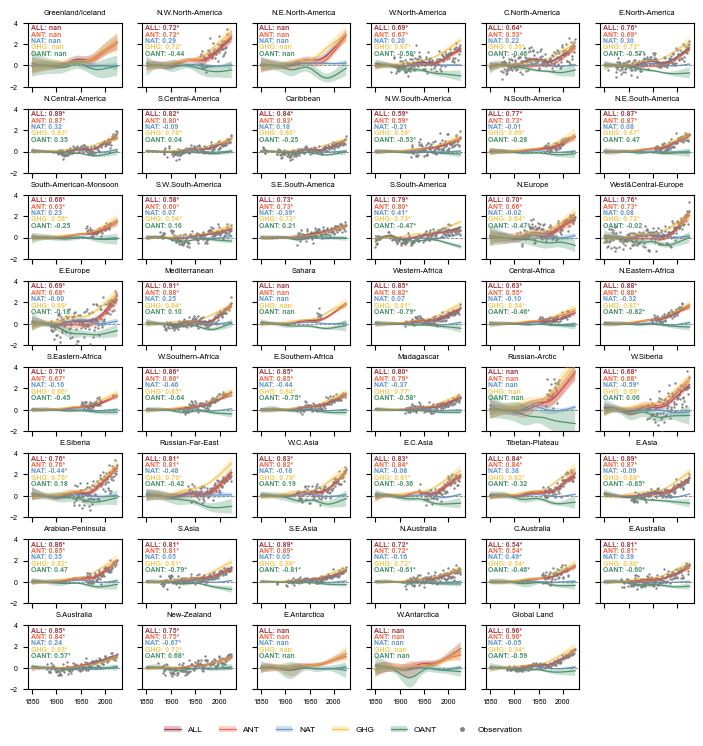

In [34]:
# Parameters
region_names = list(prior_post_smooth.names.values)

colors_forcings = ['#a23e48', '#ee6c4d', '#6699CC', '#F5CB5C', '#4C956C']

nrows, ncols = 8, 6
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(180 / 25.4, 188 / 25.4),
    sharex=True,
    sharey=True
)
axes = axes.flatten()

# Legend handles: uncertainty band with posterior-mean line overlaid.
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple

forcing_legend_labels = ['ALL', 'ANT', 'NAT', 'GHG', 'OANT']
forcing_legend_handles = [
    (
        Patch(facecolor=color, edgecolor='none', alpha=0.3),
        Line2D([0], [0], color=color, lw=0.9),
    )
    for color in colors_forcings
]
obs_legend_handle = Line2D(
    [0], [0], linestyle='none', marker='o', markersize=2.5,
    markerfacecolor='gray', markeredgecolor='gray',
)

for r_id, ax in enumerate(axes):

    if r_id >= len(region_names):
        ax.axis('off')
        continue

    data1 = prior_post_smooth.sel(scheme='prior')[r_id]
    data2 = prior_post_smooth.sel(scheme='post')[r_id]

    forcings = data2.forcing.values

    # -------------------
    # FORCING LINES
    # -------------------
    for i, forcing in enumerate(forcings):

        line, = ax.plot(
            data2['year'],
            data2.sel(quantile='mean')[i, :],
            linestyle='-',
            color=colors_forcings[i],
            lw=0.9
        )

        plot_shading(
            ax,
            data2['year'],
            data2.sel(quantile='5th')[i, :],
            data2.sel(quantile='95th')[i, :],
            color=colors_forcings[i],
            alpha=0.3
        )


    # -------------------
    # CORRELATION LABELS (stars: AR(1)-adjusted p < 0.05)
    # -------------------
    region_corr = corr_results['pearson_r'].isel(region=r_id)
    region_significant = corr_results['pearson_significant'].isel(region=r_id)
    for i, forcing in enumerate(forcings):
        corr_value = region_corr.sel(forcing=forcing).item()
        star = '*' if region_significant.sel(forcing=forcing).item() else ''
        forcing_label = 'OANT' if forcing == 'OA' else forcing
        corr_text = (
            f'{forcing_label}: {corr_value:.2f}{star}'
            if np.isfinite(corr_value) else f'{forcing_label}: nan'
        )
        ax.text(
            0.03, 0.97 - i * 0.1, corr_text,
            transform=ax.transAxes, ha='left', va='top',
            fontsize=5.0, color=colors_forcings[i], fontweight='semibold',
            zorder=5,
        )

    # -------------------
    # OBS SCATTER
    # -------------------
    obs = obs_adj_ALL_ref1850[r_id].squeeze('forcing')

    obs_scatter = ax.scatter(
        obs['year'],
        obs,
        zorder=3,
        s=0.5,
        color='gray'
    )


    # -------------------
    # STYLE
    # -------------------
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.6)
    ax.set_ylim(-2, 4)
    ax.set_title(region_names[r_id], fontsize=5.5)
    ax.tick_params(axis='both', labelsize=5.0)

# -------------------
# GLOBAL LEGEND
# -------------------
fig.legend(
    handles=forcing_legend_handles + [obs_legend_handle],
    labels=forcing_legend_labels + ['Observation'],
    loc='lower center',
    bbox_to_anchor=(0.5, 0.006),
    ncol=6,   # 5 forcings + OBS
    fontsize=6.0,
    frameon=False,
    handler_map={tuple: HandlerTuple(ndivide=1)}
)

ED8_WIDTH_MM, ED8_HEIGHT_MM = 180, 185
fig.subplots_adjust(left=0.055, right=0.995, top=0.975, bottom=0.075, wspace=0.22, hspace=0.35)

plt.show()
savefig_exact_tight(fig, './saved_figures/ED_Fig8.pdf', ED8_WIDTH_MM, ED8_HEIGHT_MM, 'Extended Data Figure 8')
